# Live Full Body & Hand Pose Estimation with OpenVINO™

This notebook demonstrates live pose estimation with OpenVINO, using [MediaPipe](https://developers.google.com/mediapipe) models for detecting full body movements and fine hand gestures. The pipeline uses four models:

1. **Pose Detection** — locates a person in the frame
2. **Pose Landmark** — detects 33 body keypoints (face, arms, torso, legs, feet)
3. **Palm Detection** — locates hands in the frame
4. **Hand Landmark** — detects 21 keypoints per hand (wrist, finger joints, and fingertips)

This enables tracking of all bodily movements from head to toe, including individual finger positions. Final part of this notebook shows live inference results from a webcam. Additionally, you can also upload a video file.

> **NOTE**: To use a webcam, you must run this Jupyter notebook on a computer with a webcam. If you run on a server, the webcam will not work. However, you can still do inference on a video in the final step.

#### Table of contents:

- [Imports](#Imports)
- [The model](#The-model)
    - [Download and convert the models](#Download-and-convert-the-models)
    - [Load the models](#Load-the-models)
- [Processing](#Processing)
    - [Detection Decoders](#Detection-Decoders)
    - [Pose Landmark Processing](#Pose-Landmark-Processing)
    - [Hand Landmark Processing](#Hand-Landmark-Processing)
    - [Process Results](#Process-Results)
    - [Draw Overlays](#Draw-Overlays)
    - [Main Processing Function](#Main-Processing-Function)
- [Run](#Run)
    - [Run Live Pose Estimation](#Run-Live-Pose-Estimation)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/pose-estimation-webcam/pose-estimation.ipynb" />

In [1]:
%pip install -q "openvino>=2023.1.0" opencv-python tqdm

Note: you may need to restart the kernel to use updated packages.


## Imports
[back to top ⬆️](#Table-of-contents:)

In [2]:
import collections
import time
from pathlib import Path

import cv2
import numpy as np
from IPython import display
import openvino as ov

# Fetch `notebook_utils` module
import requests

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )

    open("notebook_utils.py", "w").write(r.text)

import notebook_utils as utils

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("pose-estimation.ipynb")

## The model
[back to top ⬆️](#Table-of-contents:)

### Download and convert the models
[back to top ⬆️](#Table-of-contents:)

We use four [MediaPipe](https://developers.google.com/mediapipe) models for full body and hand pose estimation:

- **Pose Detection** — an SSD-based model that detects person bounding boxes and keypoints (mid-hip, full-body-size, mid-shoulder, upper-body-size)
- **Pose Landmark Full** — detects 33 body keypoints (nose, eyes, ears, shoulders, elbows, wrists, hips, knees, ankles, feet) from a cropped person region
- **Palm Detection Full** — an SSD-based model that detects palm bounding boxes and keypoints in the full frame
- **Hand Landmark Full** — detects 21 hand keypoints (wrist, each finger's MCP/PIP/DIP/TIP joints) from a cropped hand region

All models are downloaded as TensorFlow Lite files and converted to OpenVINO IR format using `ov.convert_model`.

In [3]:
# Directory for downloaded models.
base_model_dir = Path("model")
base_model_dir.mkdir(exist_ok=True)

# MediaPipe model URLs
pose_det_url = "https://storage.googleapis.com/mediapipe-assets/pose_detection.tflite"
pose_lm_url = "https://storage.googleapis.com/mediapipe-assets/pose_landmark_full.tflite"
palm_det_url = "https://storage.googleapis.com/mediapipe-assets/palm_detection_full.tflite"
hand_lm_url = "https://storage.googleapis.com/mediapipe-assets/hand_landmark_full.tflite"

pose_det_tflite = base_model_dir / "pose_detection.tflite"
pose_lm_tflite = base_model_dir / "pose_landmark_full.tflite"
palm_det_tflite = base_model_dir / "palm_detection_full.tflite"
hand_lm_tflite = base_model_dir / "hand_landmark_full.tflite"

# Download TFLite models
for url, path in [(pose_det_url, pose_det_tflite), (pose_lm_url, pose_lm_tflite),
                  (palm_det_url, palm_det_tflite), (hand_lm_url, hand_lm_tflite)]:
    utils.download_file(url, path.name, path.parent)

# Convert to OpenVINO IR format
pose_det_ir = base_model_dir / "pose_detection.xml"
pose_lm_ir = base_model_dir / "pose_landmark_full.xml"
palm_det_ir = base_model_dir / "palm_detection_full.xml"
hand_lm_ir = base_model_dir / "hand_landmark_full.xml"

for tflite_path, ir_path in [(pose_det_tflite, pose_det_ir), (pose_lm_tflite, pose_lm_ir),
                              (palm_det_tflite, palm_det_ir), (hand_lm_tflite, hand_lm_ir)]:
    if not ir_path.exists():
        ov_model = ov.convert_model(tflite_path)
        ov.save_model(ov_model, ir_path)

print(f"Pose detection model:  {pose_det_ir}")
print(f"Pose landmark model:   {pose_lm_ir}")
print(f"Palm detection model:  {palm_det_ir}")
print(f"Hand landmark model:   {hand_lm_ir}")

pose_detection.tflite:   0%|          | 0.00/2.82M [00:00<?, ?B/s]

pose_landmark_full.tflite:   0%|          | 0.00/6.14M [00:00<?, ?B/s]

Pose detection model:  model/pose_detection.xml
Pose landmark model:   model/pose_landmark_full.xml
Palm detection model:  model/palm_detection_full.xml
Hand landmark model:   model/hand_landmark_full.xml


### Load the models
[back to top ⬆️](#Table-of-contents:)

Load all four converted models and compile them for the selected device. Select device from dropdown list for running inference using OpenVINO.

In [4]:
device = utils.device_widget()

device

Dropdown(description='Device:', index=2, options=('CPU', 'GPU', 'NPU', 'AUTO'), value='NPU')

In [5]:
import openvino.properties.hint as hints

core = ov.Core()

config = {hints.performance_mode(): hints.PerformanceMode.LATENCY}

# Compile pose detection model
pose_det_compiled = core.compile_model(
    model=core.read_model(pose_det_ir), device_name=device.value, config=config,
)

# Compile pose landmark model
pose_lm_compiled = core.compile_model(
    model=core.read_model(pose_lm_ir), device_name=device.value, config=config,
)

# Compile palm detection model
palm_compiled = core.compile_model(
    model=core.read_model(palm_det_ir), device_name=device.value, config=config,
)

# Compile hand landmark model
hand_compiled = core.compile_model(
    model=core.read_model(hand_lm_ir), device_name=device.value, config=config,
)

print("All models compiled successfully.")

All models compiled successfully.


Model input and output details for all four models:

In [6]:
for name, compiled in [("Pose detection", pose_det_compiled), ("Pose landmark", pose_lm_compiled),
                        ("Palm detection", palm_compiled), ("Hand landmark", hand_compiled)]:
    print(f"{name}:")
    print(f"  Input:  {compiled.input(0).any_name} {list(compiled.input(0).shape)}")
    for o in compiled.outputs:
        print(f"  Output: {o.any_name} {list(o.shape)}")
    print()

Pose detection:
  Input:  input_1 [1, 224, 224, 3]
  Output: Identity [1, 2254, 12]
  Output: Identity_1 [1, 2254, 1]

Pose landmark:
  Input:  input_1 [1, 256, 256, 3]
  Output: Identity [1, 195]
  Output: Identity_1 [1, 1]
  Output: Identity_2 [1, 256, 256, 1]
  Output: Identity_3 [1, 64, 64, 39]
  Output: Identity_4 [1, 117]

Palm detection:
  Input:  input_1 [1, 192, 192, 3]
  Output: Identity [1, 2016, 18]
  Output: Identity_1 [1, 2016, 1]

Hand landmark:
  Input:  input_1 [1, 224, 224, 3]
  Output: Identity [1, 63]
  Output: Identity_1 [1, 1]
  Output: Identity_2 [1, 1]
  Output: Identity_3 [1, 63]



### Detection Decoders
[back to top ⬆️](#Table-of-contents:)

Both detection models (pose and palm) use SSD-style architectures with pre-computed anchors. The pose detection model uses 2254 anchors across 5 feature map layers (strides 8, 16, 32, 32, 32) with 12 values per anchor (box + 4 keypoints). The palm detection model uses 2016 anchors across 4 layers (strides 8, 16, 16, 16) with 18 values per anchor (box + 7 keypoints). Both decoders generate anchors, decode outputs, and apply non-maximum suppression.

In [7]:
PALM_INPUT_SIZE = 192
HAND_INPUT_SIZE = 224
POSE_INPUT_SIZE = 224
POSE_LM_INPUT_SIZE = 256


def generate_anchors(input_size, strides):
    """Generate SSD anchors for MediaPipe detection models.

    Layers with the same stride are grouped so that anchors at each grid cell
    are interleaved across sub-layers, matching the model's expected order.
    """
    anchors = []
    layer_id = 0
    while layer_id < len(strides):
        stride = strides[layer_id]
        same_stride_count = 0
        while (layer_id + same_stride_count < len(strides)
               and strides[layer_id + same_stride_count] == stride):
            same_stride_count += 1
        grid_size = input_size // stride
        for y in range(grid_size):
            for x in range(grid_size):
                for _ in range(same_stride_count):
                    for _ in range(2):
                        anchors.append([(x + 0.5) / grid_size, (y + 0.5) / grid_size])
        layer_id += same_stride_count
    return np.array(anchors, dtype=np.float32)


def nms(boxes, scores, iou_threshold=0.3):
    """Non-maximum suppression."""
    if len(boxes) == 0:
        return []

    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    keep = []

    while len(order) > 0:
        i = order[0]
        keep.append(i)
        if len(order) == 1:
            break

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        intersection = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        iou = intersection / (areas[i] + areas[order[1:]] - intersection + 1e-6)

        remaining = np.where(iou <= iou_threshold)[0]
        order = order[remaining + 1]

    return keep


def decode_detections(raw_boxes, raw_scores, anchors, input_size, num_keypoints,
                      score_threshold=0.5, iou_threshold=0.3):
    """Decode detection model outputs into detection results.

    Works for both pose detection (4 keypoints, 12 values) and palm detection
    (7 keypoints, 18 values). Each detection contains a bounding box, confidence
    score, and keypoints in normalized [0, 1] coordinates.
    """
    values_per_anchor = 4 + num_keypoints * 2
    scores = 1.0 / (1.0 + np.exp(-raw_scores.reshape(-1)))

    mask = scores >= score_threshold
    if not np.any(mask):
        return []

    filtered_scores = scores[mask]
    filtered_boxes = raw_boxes.reshape(-1, values_per_anchor)[mask]
    filtered_anchors = anchors[mask]

    cx = filtered_boxes[:, 0] / input_size + filtered_anchors[:, 0]
    cy = filtered_boxes[:, 1] / input_size + filtered_anchors[:, 1]
    w = filtered_boxes[:, 2] / input_size
    h = filtered_boxes[:, 3] / input_size

    boxes = np.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], axis=-1)

    keypoints = np.zeros((len(filtered_boxes), num_keypoints, 2))
    for k in range(num_keypoints):
        keypoints[:, k, 0] = filtered_boxes[:, 4 + 2 * k] / input_size + filtered_anchors[:, 0]
        keypoints[:, k, 1] = filtered_boxes[:, 4 + 2 * k + 1] / input_size + filtered_anchors[:, 1]

    indices = nms(boxes, filtered_scores, iou_threshold)

    detections = []
    for i in indices:
        detections.append({
            "box": boxes[i],
            "score": filtered_scores[i],
            "keypoints": keypoints[i],
        })
    return detections


# Pre-generate anchors for both detection models
palm_anchors = generate_anchors(PALM_INPUT_SIZE, strides=[8, 16, 16, 16])
pose_anchors = generate_anchors(POSE_INPUT_SIZE, strides=[8, 16, 32, 32, 32])
print(f"Generated {len(palm_anchors)} palm anchors, {len(pose_anchors)} pose anchors")

Generated 2016 palm anchors, 2254 pose anchors


## Processing
[back to top ⬆️](#Table-of-contents:)

In [8]:
# Body skeleton connections (33 keypoints, MediaPipe BlazePose format)
# 0:nose, 1-6:eyes, 7-8:ears, 9-10:mouth, 11-12:shoulders, 13-14:elbows,
# 15-16:wrists, 17-22:hand tips, 23-24:hips, 25-26:knees, 27-28:ankles,
# 29-30:heels, 31-32:foot index
BODY_CONNECTIONS = [
    # Face
    (0, 1), (1, 2), (2, 3), (3, 7),
    (0, 4), (4, 5), (5, 6), (6, 8),
    (9, 10),
    # Torso
    (11, 12), (11, 23), (12, 24), (23, 24),
    # Left arm
    (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), (17, 19),
    # Right arm
    (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20),
    # Left leg
    (23, 25), (25, 27), (27, 29), (27, 31), (29, 31),
    # Right leg
    (24, 26), (26, 28), (28, 30), (28, 32), (30, 32),
]

# Hand skeleton connections (21 keypoints, MediaPipe format)
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),           # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),           # Index finger
    (5, 9), (9, 10), (10, 11), (11, 12),      # Middle finger
    (9, 13), (13, 14), (14, 15), (15, 16),    # Ring finger
    (13, 17), (17, 18), (18, 19), (19, 20),   # Pinky
    (0, 17),                                    # Palm base
]


def get_pose_crop(img, detection, scale_factor=2.6, target_size=256):
    """Extract a person crop using pose detection keypoints (mid-hip and full-body-size)."""
    img_h, img_w = img.shape[:2]
    kp_hip = detection["keypoints"][0] * np.array([img_w, img_h])
    kp_full = detection["keypoints"][1] * np.array([img_w, img_h])

    cx = (kp_hip[0] + kp_full[0]) / 2
    cy = (kp_hip[1] + kp_full[1]) / 2

    dx = kp_full[0] - kp_hip[0]
    dy = kp_full[1] - kp_hip[1]
    rotation = np.degrees(np.arctan2(dx, -dy))
    body_size = np.sqrt(dx**2 + dy**2) * scale_factor

    cos_r = np.cos(np.radians(-rotation))
    sin_r = np.sin(np.radians(-rotation))
    scale = target_size / body_size

    M = np.array([
        [cos_r * scale, -sin_r * scale, target_size / 2 - (cx * cos_r - cy * sin_r) * scale],
        [sin_r * scale,  cos_r * scale, target_size / 2 - (cx * sin_r + cy * cos_r) * scale],
    ], dtype=np.float32)

    cropped = cv2.warpAffine(img, M, (target_size, target_size))
    return cropped, M


def get_hand_crop(img, detection, scale_factor=2.6, target_size=224):
    """Extract a hand crop using palm detection keypoints (wrist and middle finger MCP)."""
    img_h, img_w = img.shape[:2]
    kp_wrist = detection["keypoints"][0] * np.array([img_w, img_h])
    kp_middle = detection["keypoints"][2] * np.array([img_w, img_h])

    box = detection["box"] * np.array([img_w, img_h, img_w, img_h])
    cx = (box[0] + box[2]) / 2
    cy = (box[1] + box[3]) / 2
    box_size = max(box[2] - box[0], box[3] - box[1]) * scale_factor

    rotation = np.degrees(np.arctan2(kp_middle[0] - kp_wrist[0], -(kp_middle[1] - kp_wrist[1])))
    shift = box_size * 0.05
    cx += shift * np.sin(np.radians(rotation))
    cy -= shift * np.cos(np.radians(rotation))

    cos_r = np.cos(np.radians(-rotation))
    sin_r = np.sin(np.radians(-rotation))
    scale = target_size / box_size

    M = np.array([
        [cos_r * scale, -sin_r * scale, target_size / 2 - (cx * cos_r - cy * sin_r) * scale],
        [sin_r * scale,  cos_r * scale, target_size / 2 - (cx * sin_r + cy * cos_r) * scale],
    ], dtype=np.float32)

    cropped = cv2.warpAffine(img, M, (target_size, target_size))
    return cropped, M


def transform_landmarks_to_image(landmarks, M):
    """Transform landmarks from crop coordinates back to original image coordinates."""
    M_full = np.vstack([M, [0, 0, 1]])
    M_inv = np.linalg.inv(M_full)[:2]

    ones = np.ones((landmarks.shape[0], 1))
    pts = np.hstack([landmarks[:, :2], ones])
    original_pts = (M_inv @ pts.T).T

    result = np.copy(landmarks)
    result[:, 0] = original_pts[:, 0]
    result[:, 1] = original_pts[:, 1]
    return result

### Process Results
[back to top ⬆️](#Table-of-contents:)

The processing pipeline runs both pose detection and palm detection on the full frame. For each detected person, it extracts a rotated crop and runs the pose landmark model to get 33 body keypoints. For each detected palm, it extracts a hand crop and runs the hand landmark model to get 21 hand keypoints. All landmarks are transformed back to original image coordinates.

In [9]:
def run_detection(frame, compiled_model, input_size, anchors, num_keypoints):
    """Run a detection model (pose or palm) on a frame."""
    input_img = cv2.resize(frame, (input_size, input_size))
    input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
    input_img = input_img.astype(np.float32) / 255.0

    input_shape = list(compiled_model.input(0).shape)
    if input_shape[-1] == 3:
        input_tensor = np.expand_dims(input_img, 0)
    else:
        input_tensor = np.expand_dims(input_img.transpose(2, 0, 1), 0)

    results = compiled_model([input_tensor])

    values_per_anchor = 4 + num_keypoints * 2
    out0 = results[compiled_model.output(0)]
    out1 = results[compiled_model.output(1)]
    if out0.shape[-1] == values_per_anchor:
        raw_boxes, raw_scores = out0, out1
    else:
        raw_boxes, raw_scores = out1, out0

    return decode_detections(raw_boxes, raw_scores, anchors, input_size, num_keypoints)


def detect_pose_landmarks(frame, detection):
    """Run pose landmark detection on a person region. Returns 33 body keypoints and visibility."""
    cropped, M = get_pose_crop(frame, detection, target_size=POSE_LM_INPUT_SIZE)

    input_img = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    input_img = input_img.astype(np.float32) / 255.0

    input_shape = list(pose_lm_compiled.input(0).shape)
    if input_shape[-1] == 3:
        input_tensor = np.expand_dims(input_img, 0)
    else:
        input_tensor = np.expand_dims(input_img.transpose(2, 0, 1), 0)

    results = pose_lm_compiled([input_tensor])

    # Find outputs: landmarks (39*5=195 values), pose flag (1 value)
    landmarks = None
    pose_flag = None

    for output in pose_lm_compiled.outputs:
        data = results[output].squeeze()
        if data.size == 195:
            landmarks = data.reshape(39, 5)
        elif data.size == 1 and pose_flag is None:
            pose_flag = 1.0 / (1.0 + np.exp(-float(data)))

    if landmarks is None or pose_flag is None:
        return None, None, 0.0

    # Use first 33 landmarks (standard body keypoints), extract x, y, z
    body_lm = landmarks[:33, :3].copy()
    body_lm = transform_landmarks_to_image(body_lm, M)
    visibility = 1.0 / (1.0 + np.exp(-landmarks[:33, 3]))

    return body_lm, visibility, float(pose_flag)


def detect_hand_landmarks(frame, detection):
    """Run hand landmark detection on a palm region. Returns 21 keypoints and confidence."""
    cropped, M = get_hand_crop(frame, detection, target_size=HAND_INPUT_SIZE)

    input_img = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    input_img = input_img.astype(np.float32) / 255.0

    input_shape = list(hand_compiled.input(0).shape)
    if input_shape[-1] == 3:
        input_tensor = np.expand_dims(input_img, 0)
    else:
        input_tensor = np.expand_dims(input_img.transpose(2, 0, 1), 0)

    results = hand_compiled([input_tensor])

    landmarks = None
    hand_flag = None

    landmark_candidates = []
    for output in hand_compiled.outputs:
        data = results[output].squeeze()
        if data.size == 63:
            landmark_candidates.append(data.reshape(21, 3))
        elif data.size == 1 and hand_flag is None:
            hand_flag = 1.0 / (1.0 + np.exp(-float(data)))

    if not landmark_candidates or hand_flag is None:
        return None, 0.0

    if len(landmark_candidates) == 1:
        landmarks = landmark_candidates[0]
    else:
        landmarks = max(landmark_candidates, key=lambda lm: np.abs(lm[:, :2]).max())

    landmarks = transform_landmarks_to_image(landmarks, M)
    return landmarks, float(hand_flag)


def process_frame(frame, det_score_threshold=0.5, lm_score_threshold=0.5):
    """Full pipeline: detect body poses and hand landmarks."""
    # Body pose estimation
    pose_detections = run_detection(frame, pose_det_compiled, POSE_INPUT_SIZE, pose_anchors, 4)
    body_landmarks = []
    body_visibilities = []
    for det in pose_detections:
        if det["score"] < det_score_threshold:
            continue
        lm, vis, confidence = detect_pose_landmarks(frame, det)
        if lm is not None and confidence > lm_score_threshold:
            body_landmarks.append(lm)
            body_visibilities.append(vis)

    # Hand pose estimation
    palm_detections = run_detection(frame, palm_compiled, PALM_INPUT_SIZE, palm_anchors, 7)
    hand_landmarks = []
    for det in palm_detections:
        if det["score"] < det_score_threshold:
            continue
        lm, confidence = detect_hand_landmarks(frame, det)
        if lm is not None and confidence > lm_score_threshold:
            hand_landmarks.append(lm)

    return body_landmarks, body_visibilities, hand_landmarks

### Draw Overlays
[back to top ⬆️](#Table-of-contents:)

Draw pose overlays on the image to visualize both body and hand landmarks. Body parts are color-coded by region (face, torso, left/right arms, left/right legs), and each finger is drawn in a distinct color.

In [10]:
# Body part colors (BGR)
FACE_COLOR = (200, 200, 200)
TORSO_COLOR = (0, 255, 255)
LEFT_ARM_COLOR = (0, 200, 0)
RIGHT_ARM_COLOR = (0, 128, 255)
LEFT_LEG_COLOR = (200, 0, 200)
RIGHT_LEG_COLOR = (255, 0, 128)

# One color per body connection, matching BODY_CONNECTIONS order
BODY_CONNECTION_COLORS = (
    [FACE_COLOR] * 9
    + [TORSO_COLOR] * 4
    + [LEFT_ARM_COLOR] * 6
    + [RIGHT_ARM_COLOR] * 6
    + [LEFT_LEG_COLOR] * 5
    + [RIGHT_LEG_COLOR] * 5
)

# Hand finger colors (BGR)
THUMB_COLOR = (0, 0, 255)
INDEX_COLOR = (0, 128, 255)
MIDDLE_COLOR = (0, 255, 0)
RING_COLOR = (255, 128, 0)
PINKY_COLOR = (255, 0, 128)
PALM_COLOR = (180, 180, 180)

HAND_CONNECTION_COLORS = (
    [THUMB_COLOR] * 4
    + [INDEX_COLOR] * 4
    + [MIDDLE_COLOR] * 4
    + [RING_COLOR] * 4
    + [PINKY_COLOR] * 4
    + [PALM_COLOR]
)

HAND_KEYPOINT_COLORS = (
    [PALM_COLOR]
    + [THUMB_COLOR] * 4
    + [INDEX_COLOR] * 4
    + [MIDDLE_COLOR] * 4
    + [RING_COLOR] * 4
    + [PINKY_COLOR] * 4
)


def draw_body_landmarks(img, body_landmarks, body_visibilities, visibility_threshold=0.5):
    """Draw body pose landmarks and skeleton connections on the image."""
    if not body_landmarks:
        return img

    img_limbs = np.copy(img)

    for landmarks, visibility in zip(body_landmarks, body_visibilities):
        points = landmarks[:, :2].astype(np.int32)

        for idx, (i, j) in enumerate(BODY_CONNECTIONS):
            if visibility[i] > visibility_threshold and visibility[j] > visibility_threshold:
                cv2.line(img_limbs, tuple(points[i]), tuple(points[j]),
                         BODY_CONNECTION_COLORS[idx], 2, cv2.LINE_AA)

        for idx, pt in enumerate(points):
            if visibility[idx] > visibility_threshold:
                cv2.circle(img, tuple(pt), 4, TORSO_COLOR, -1, cv2.LINE_AA)
                cv2.circle(img, tuple(pt), 4, (255, 255, 255), 1, cv2.LINE_AA)

    cv2.addWeighted(img, 0.4, img_limbs, 0.6, 0, dst=img)
    return img


def draw_hand_landmarks(img, hand_landmarks):
    """Draw hand landmarks and skeleton connections on the image."""
    if not hand_landmarks:
        return img

    img_limbs = np.copy(img)

    for landmarks in hand_landmarks:
        points = landmarks[:, :2].astype(np.int32)

        for idx, (i, j) in enumerate(HAND_CONNECTIONS):
            cv2.line(img_limbs, tuple(points[i]), tuple(points[j]),
                     HAND_CONNECTION_COLORS[idx], 2, cv2.LINE_AA)

        for idx, pt in enumerate(points):
            cv2.circle(img, tuple(pt), 3, HAND_KEYPOINT_COLORS[idx], -1, cv2.LINE_AA)
            cv2.circle(img, tuple(pt), 3, (255, 255, 255), 1, cv2.LINE_AA)

    cv2.addWeighted(img, 0.4, img_limbs, 0.6, 0, dst=img)
    return img

### Main Processing Function
[back to top ⬆️](#Table-of-contents:)

Run full body and hand pose estimation on the specified source. Either a webcam or a video file.

In [11]:
def run_pose_estimation(source=0, flip=False, use_popup=False, skip_first_frames=0):
    """Main processing function to run full body and hand pose estimation."""
    player = None
    try:
        player = utils.VideoPlayer(source, flip=flip, fps=30, skip_first_frames=skip_first_frames)
        player.start()
        if use_popup:
            title = "Press ESC to Exit"
            cv2.namedWindow(title, cv2.WINDOW_GUI_NORMAL | cv2.WINDOW_AUTOSIZE)

        processing_times = collections.deque()

        while True:
            frame = player.next()
            if frame is None:
                print("Source ended")
                break

            # Limit frame size for performance.
            scale = 1280 / max(frame.shape)
            if scale < 1:
                frame = cv2.resize(frame, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

            start_time = time.time()
            body_landmarks, body_visibilities, hand_landmarks = process_frame(frame)
            stop_time = time.time()

            frame = draw_body_landmarks(frame, body_landmarks, body_visibilities)
            frame = draw_hand_landmarks(frame, hand_landmarks)

            processing_times.append(stop_time - start_time)
            if len(processing_times) > 200:
                processing_times.popleft()

            _, f_width = frame.shape[:2]
            processing_time = np.mean(processing_times) * 1000
            fps = 1000 / processing_time
            cv2.putText(
                frame,
                f"Inference time: {processing_time:.1f}ms ({fps:.1f} FPS)",
                (20, 40),
                cv2.FONT_HERSHEY_COMPLEX,
                f_width / 1000,
                (0, 0, 255),
                1,
                cv2.LINE_AA,
            )

            if use_popup:
                cv2.imshow(title, frame)
                key = cv2.waitKey(1)
                if key == 27:
                    break
            else:
                _, encoded_img = cv2.imencode(".jpg", frame, params=[cv2.IMWRITE_JPEG_QUALITY, 90])
                i = display.Image(data=encoded_img)
                display.clear_output(wait=True)
                display.display(i)
    except KeyboardInterrupt:
        print("Interrupted")
    except RuntimeError as e:
        print(e)
    finally:
        if player is not None:
            player.stop()
        if use_popup:
            cv2.destroyAllWindows()

## Run
[back to top ⬆️](#Table-of-contents:)

### Run Live Pose Estimation
[back to top ⬆️](#Table-of-contents:)

Use a webcam as the video input. By default, the primary webcam is set with `source=0`. If you have multiple webcams, each one will be assigned a consecutive number starting at 0. Set `flip=True` when using a front-facing camera. Some web browsers, especially Mozilla Firefox, may cause flickering. If you experience flickering, set `use_popup=True`.

> **NOTE**: To use this notebook with a webcam, you need to run the notebook on a computer with a webcam. If you run the notebook on a server (for example, Binder), the webcam will not work. Popup mode may not work if you run this notebook on a remote computer (for example, Binder).

If you do not have a webcam, you can still run this demo with a video file. Any [format supported by OpenCV](https://docs.opencv.org/4.5.1/dd/d43/tutorial_py_video_display.html) will work. You can skip first `N` frames to fast forward video.

Run full body and hand pose estimation:

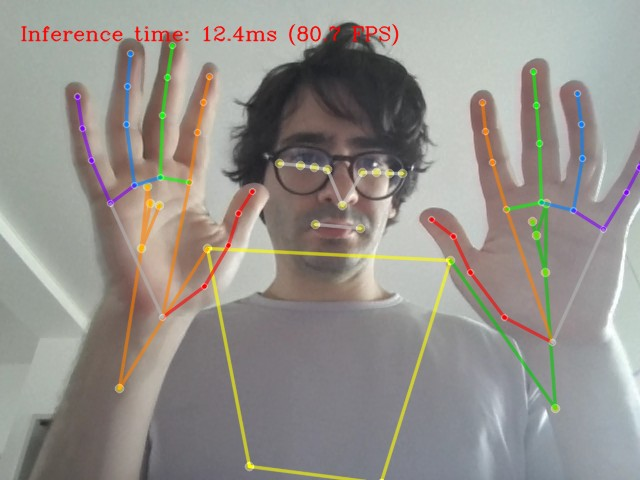

In [ ]:
USE_WEBCAM = True
cam_id = 0
video_file = Path("store-aisle-detection.mp4")
video_url = "https://storage.openvinotoolkit.org/data/test_data/videos/store-aisle-detection.mp4"
source = cam_id if USE_WEBCAM else video_file

if not USE_WEBCAM and not Path(video_file).exists():
    utils.download_file(video_url)

additional_options = {"skip_first_frames": 500} if not USE_WEBCAM else {}
run_pose_estimation(source=source, flip=isinstance(source, int), use_popup=False, **additional_options)